In [ ]:
# 최근 3년 삼성전자 OHLCV
# → 기술지표 생성
# → AutoEncoder 이상점수 계산
# → 이상점수를 LSTM 입력변수에 추가
# → 향후 5거래일 추세 전환 예측
# → 성능평가 및 CSV 저장

In [2]:
import sys
import subprocess

packages = [
    "pykrx",
    "tensorflow==2.15.1",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "python-dateutil"
]

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--upgrade",
    *packages
])

print("패키지 설치 완료")
print("주피터 메뉴에서 Kernel → Restart를 실행하세요.")

패키지 설치 완료
주피터 메뉴에서 Kernel → Restart를 실행하세요.


In [2]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--force-reinstall",
    "setuptools==80.9.0"
])

print("설치 완료")
print("반드시 주피터 커널을 재시작하세요.")

설치 완료
반드시 주피터 커널을 재시작하세요.


In [1]:
import setuptools
import pkg_resources

print("setuptools 버전:", setuptools.__version__)
print("pkg_resources 불러오기 성공")

C:\Users\JYB\AppData\Local\Temp\ipykernel_17268\4045520061.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


setuptools 버전: 80.9.0
pkg_resources 불러오기 성공



Python 환경 확인 완료
TensorFlow 버전: 2.15.1

삼성전자 최근 3년 주가 데이터 수집
조회 시작일: 20230731
조회 종료일: 20260731

데이터 다운로드 시도: 1/3
데이터 다운로드 성공

pykrx 원본 컬럼
['시가', '고가', '저가', '종가', '거래량', '등락률']

수집 결과
종목: 삼성전자
종목코드: 005930
실제 시작일: 2023-07-31 00:00:00
실제 종료일: 2026-07-30 00:00:00
전체 거래일: 729

앞부분
             Open   High    Low  Close    Volume
날짜                                              
2023-07-31  70900  71000  69800  69800  13035420
2023-08-01  70100  71200  70000  71100  12299254
2023-08-02  70700  71000  69800  69900  13835020
2023-08-03  69900  70200  68500  68800  20087090
2023-08-04  68800  69100  68200  68300  12360193

최근 5거래일
              Open    High     Low   Close    Volume
날짜                                                  
2026-07-24  266000  266500  247000  249500  26175580
2026-07-27  257000  258500  246000  254000  23296044
2026-07-28  238500  240000  218500  220000  41639623
2026-07-29  226500  234000  189200  208500  65555523
2026-07-30  214000  226000  202000  207000  4615051

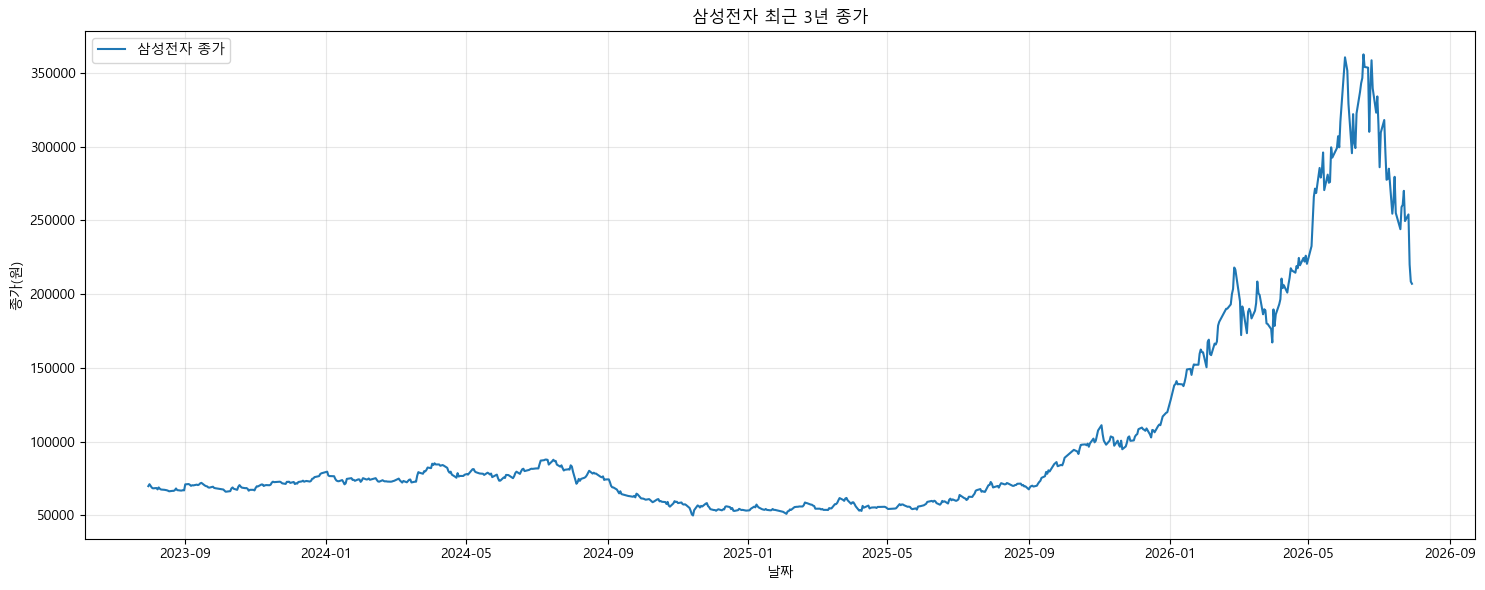


기술지표 및 Label 생성 결과
사용 가능한 최종 관측치: 665

추세 전환 Label 개수
Target
0    461
1    204
Name: count, dtype: int64

추세 전환 Label 비율
Target
0    0.6932
1    0.3068
Name: proportion, dtype: float64


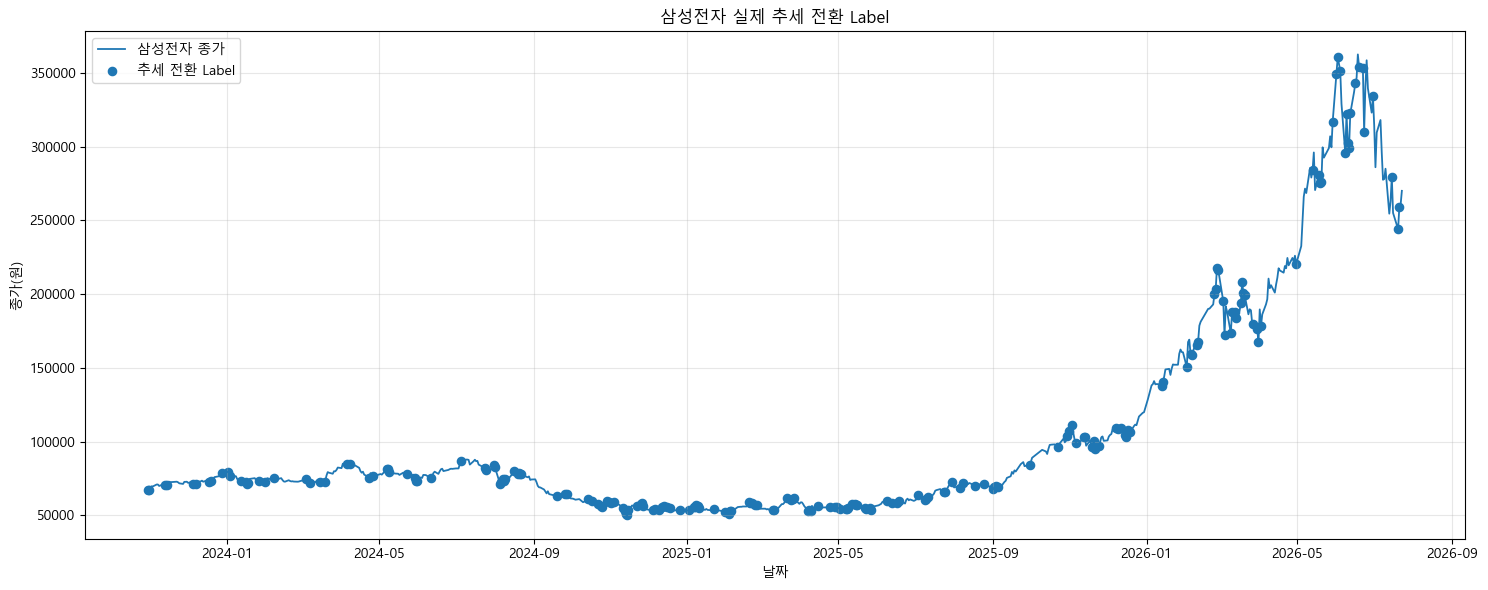


시계열 데이터 분할
Train: 2023-10-30 00:00:00 ~ 2025-06-20 00:00:00 | 399 개
Validation: 2025-06-23 00:00:00 ~ 2026-01-06 00:00:00 | 133 개
Test: 2026-01-07 00:00:00 ~ 2026-07-23 00:00:00 | 133 개

Train Label
Target
0    276
1    123
Name: count, dtype: int64

Validation Label
Target
0    99
1    34
Name: count, dtype: int64

Test Label
Target
0    86
1    47
Name: count, dtype: int64

AutoEncoder 데이터 크기
Train: (399, 11)
Validation: (133, 11)
Test: (133, 11)


AutoEncoder 구조
Model: "Stock_AutoEncoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 AutoEncoder_Input (InputLa  [(None, 11)]              0         
 yer)                                                            
                                                                 
 Encoder_1 (Dense)           (None, 16)                192       
                                                                 
 Encoder_2 (Dense)           (None, 8)  

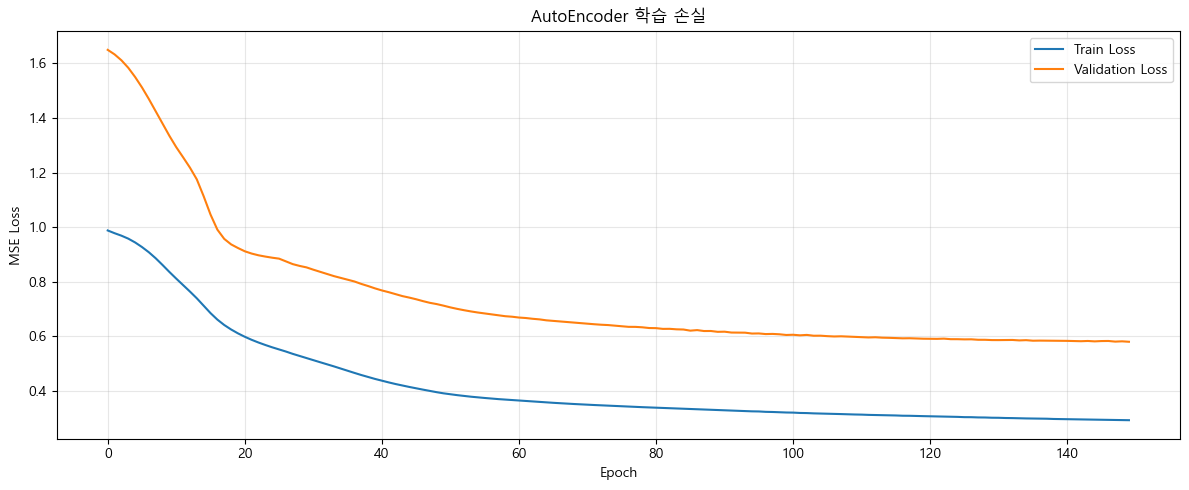


AutoEncoder 이상탐지 결과
이상점수 임계값: 0.779999
Train 이상치: 20
Validation 이상치: 24
Test 이상치: 127


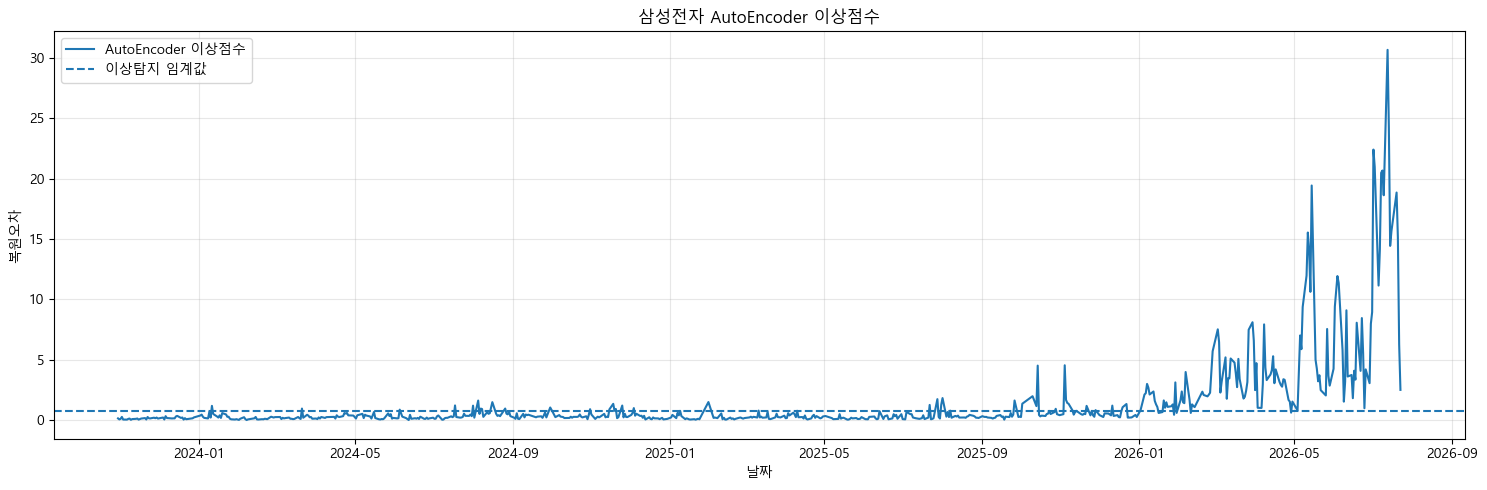

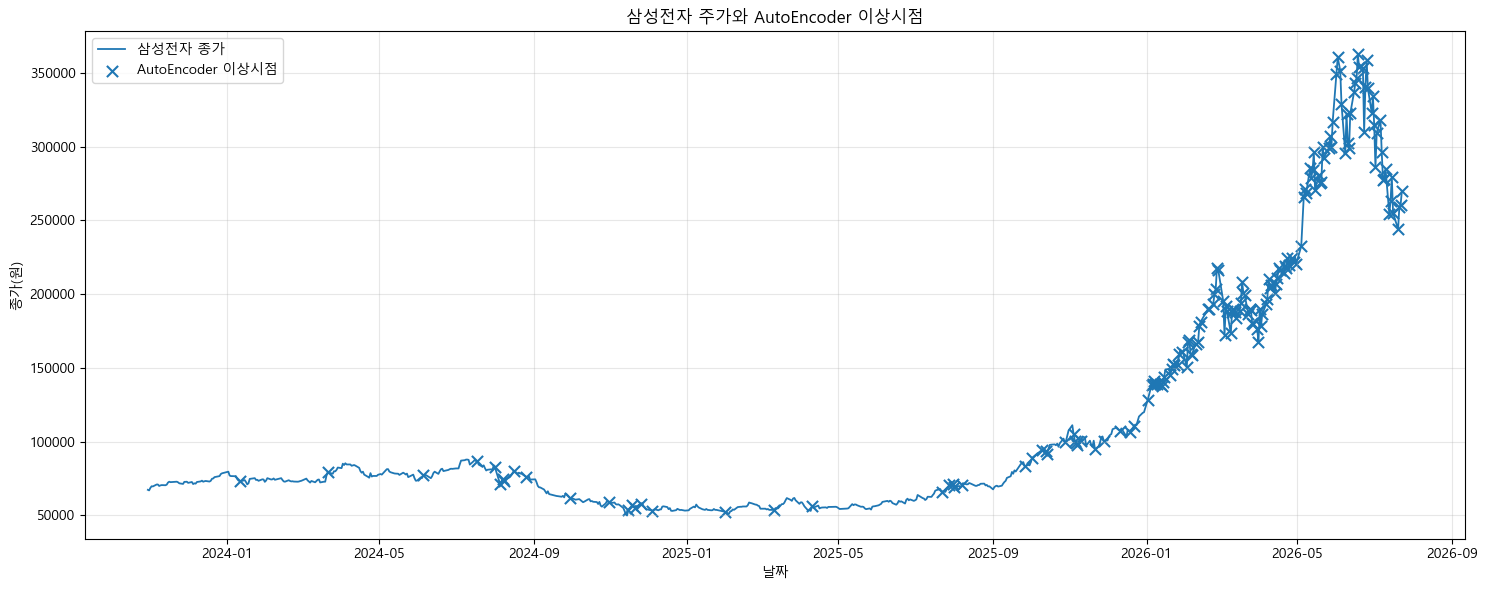


전체 LSTM 시퀀스 크기
X: (645, 20, 12)
y: (645,)

LSTM 데이터 분할 결과
X_train: (379, 20, 12)
y_train: (379,)
X_valid: (133, 20, 12)
y_valid: (133,)
X_test: (133, 20, 12)
y_test: (133,)

Train 정상: 260
Train 추세 전환: 119
클래스 가중치: {0: 0.7288461538461538, 1: 1.5924369747899159}

LSTM 구조
Model: "Anomaly_LSTM_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 20, 64)            19712     
                                                                 
 dropout (Dropout)           (None, 20, 64)            0         
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)  

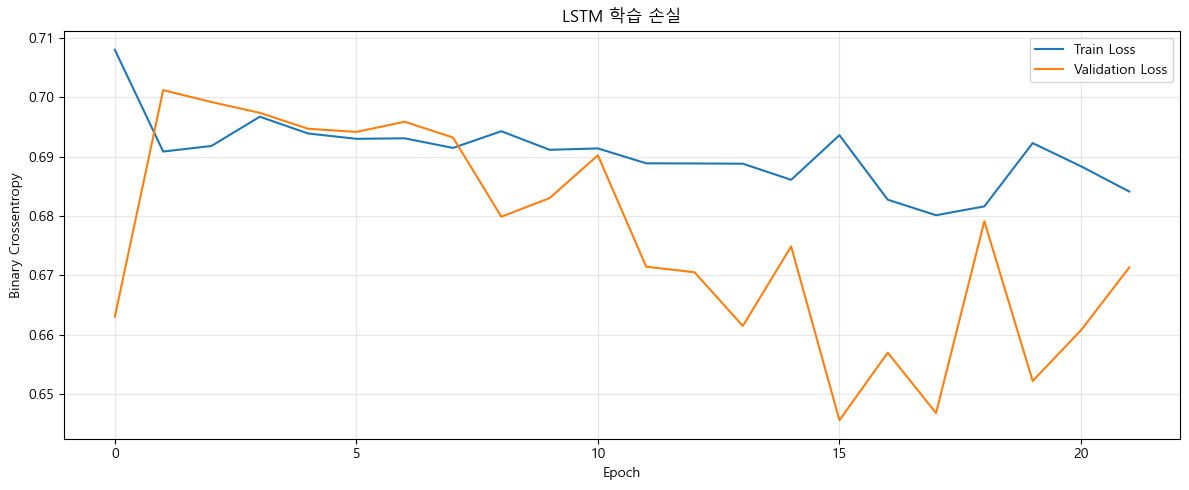

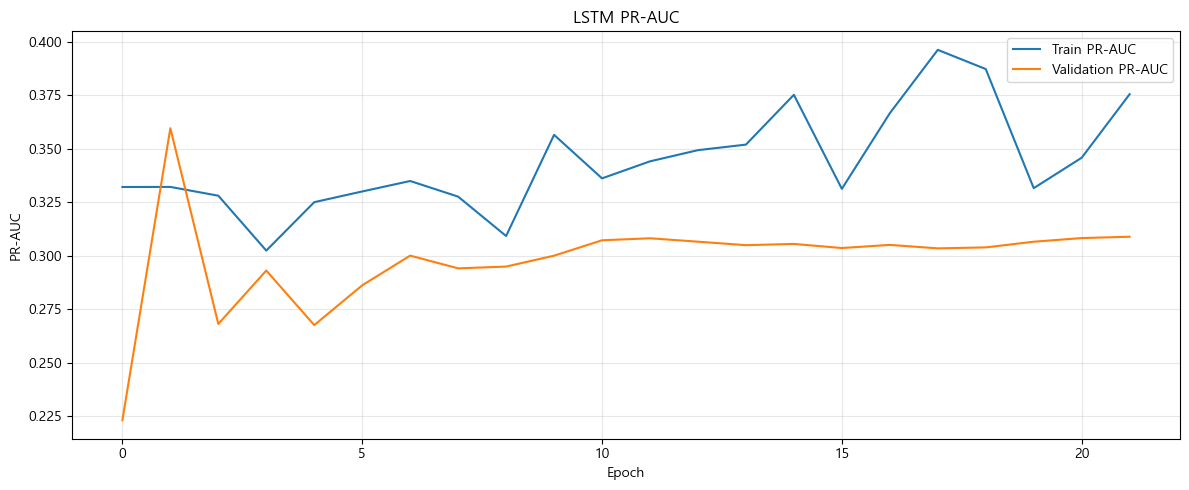


Validation 최적 임계값
최적 임계값: 0.5
Validation F1: 0.4096

Test 성능평가
      Metric   Score
0   Accuracy  0.3308
1  Precision  0.3158
2     Recall  0.7660
3         F1  0.4472
4    ROC-AUC  0.4070
5     PR-AUC  0.3028

혼동행렬
          예측 정상  예측 추세 전환
실제 정상         8        78
실제 추세 전환     11        36

분류 성능 상세
              precision    recall  f1-score   support

          정상     0.4211    0.0930    0.1524        86
       추세 전환     0.3158    0.7660    0.4472        47

    accuracy                         0.3308       133
   macro avg     0.3684    0.4295    0.2998       133
weighted avg     0.3839    0.3308    0.2566       133


최근 20개 예측 결과
             Close  Anomaly_Score  Anomaly_Flag  Actual_Reversal  \
Date                                                               
2026-06-25  358500       0.992427             1                0   
2026-06-26  339500       4.206569             1                0   
2026-06-29  323000       3.067660             1                0   
2026-06-30  33

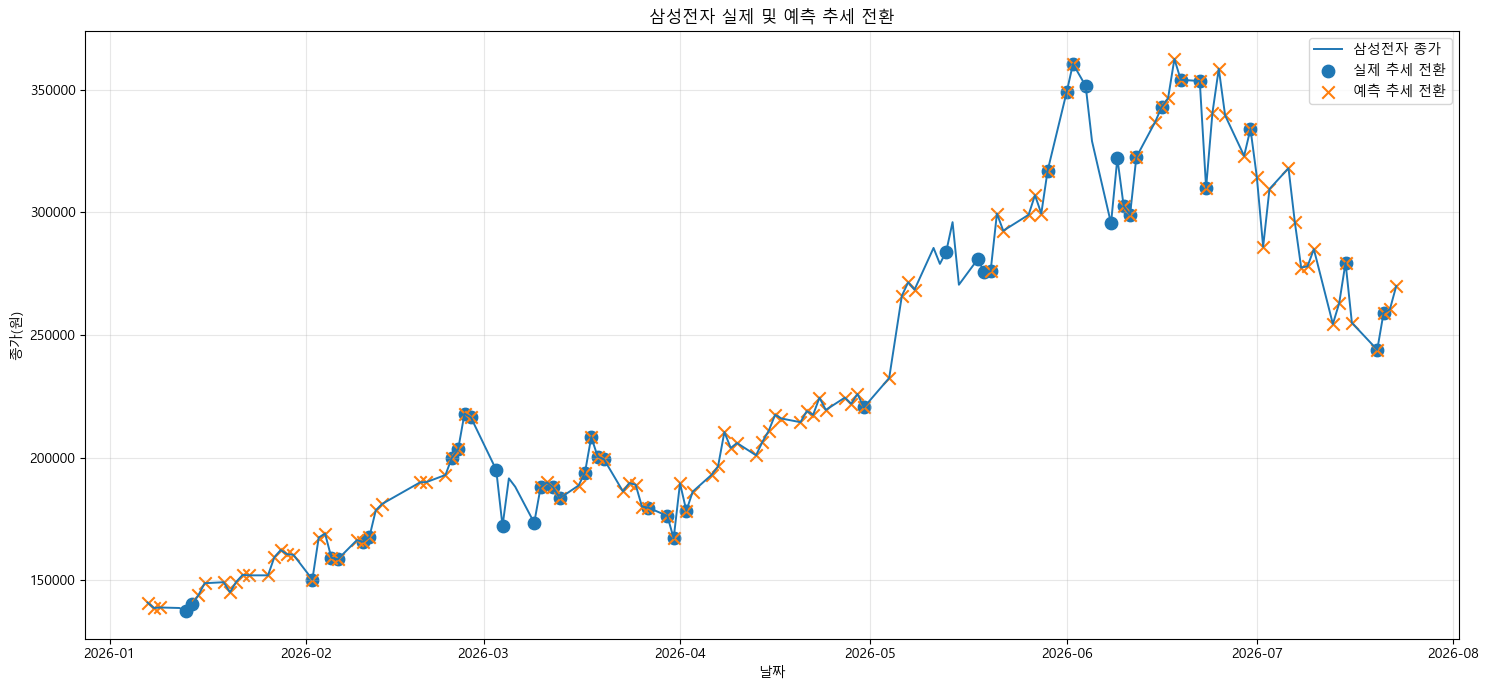

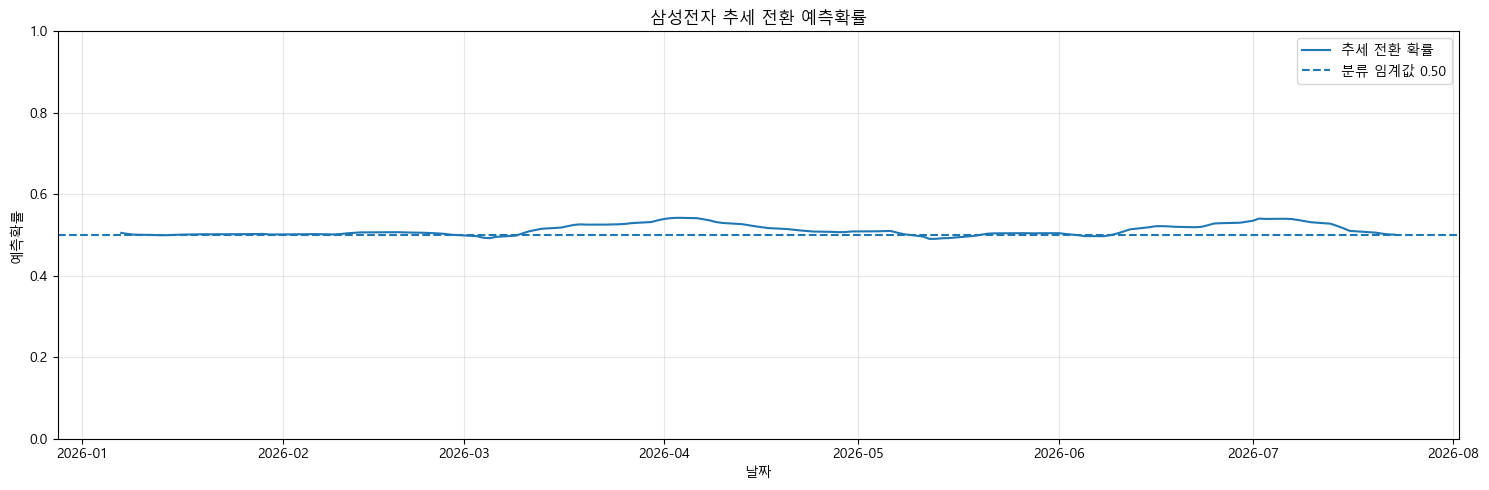


가장 최근 평가 가능한 시점
날짜: 2026-07-23
종가: 270,000원
AutoEncoder 이상점수: 2.511434
이상시점 여부: 이상
추세 전환 예측확률: 50.06%
추세 전환 예측: 추세 전환

전체 분석 완료
저장된 파일
1. samsung_raw_3years.csv
2. samsung_3years_features_anomaly.csv
3. samsung_3years_lstm_prediction.csv
4. samsung_3years_model_performance.csv
5. samsung_3years_confusion_matrix.csv
6. samsung_autoencoder.keras
7. samsung_anomaly_lstm.keras


In [2]:
# ============================================================
# 삼성전자 최근 3년
# pykrx + AutoEncoder + LSTM
# 이상거래 탐지 및 주가 추세 전환 예측
# ============================================================

import time
import random
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from dateutil.relativedelta import relativedelta
from pykrx import stock

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    LSTM,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping


# ============================================================
# 0. 기본 설정
# ============================================================

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Windows 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

print("Python 환경 확인 완료")
print("TensorFlow 버전:", tf.__version__)


# ============================================================
# 1. 사용자 설정값
# ============================================================

TICKER = "005930"
COMPANY_NAME = "삼성전자"

# 예측 시점으로부터 향후 몇 거래일을 볼 것인가
FORECAST_HORIZON = 5

# 추세 전환으로 판단할 최소 미래 수익률
RETURN_THRESHOLD = 0.02

# AutoEncoder 이상점수 상위 몇 %를 이상으로 볼 것인가
ANOMALY_QUANTILE = 0.95

# LSTM이 사용할 과거 거래일 수
WINDOW_SIZE = 20

# 데이터 분할 비율
TRAIN_RATIO = 0.60
VALID_RATIO = 0.20
TEST_RATIO = 0.20


# ============================================================
# 2. 삼성전자 최근 3년 데이터 수집
# ============================================================

end_date = datetime.today()
start_date = end_date - relativedelta(years=3)

start_str = start_date.strftime("%Y%m%d")
end_str = end_date.strftime("%Y%m%d")

print("\n" + "=" * 70)
print("삼성전자 최근 3년 주가 데이터 수집")
print("=" * 70)

print("조회 시작일:", start_str)
print("조회 종료일:", end_str)


def download_pykrx_data(
    ticker,
    start,
    end,
    max_retries=3
):
    """
    pykrx를 이용하여 주가 데이터를 가져옵니다.
    일시적인 접속 오류에 대비하여 최대 3회 재시도합니다.
    """

    last_error = None

    for attempt in range(1, max_retries + 1):

        try:
            print(
                f"\n데이터 다운로드 시도: "
                f"{attempt}/{max_retries}"
            )

            result = stock.get_market_ohlcv(
                start,
                end,
                ticker
            )

            if result is not None and not result.empty:
                print("데이터 다운로드 성공")
                return result

            print("받은 데이터가 비어 있습니다.")

        except Exception as error:
            last_error = error
            print("다운로드 오류:", error)

        if attempt < max_retries:
            print("5초 후 다시 시도합니다.")
            time.sleep(5)

    if last_error is not None:
        raise RuntimeError(
            f"pykrx 데이터 다운로드 실패: {last_error}"
        )

    raise RuntimeError(
        "pykrx 데이터 다운로드 결과가 비어 있습니다."
    )


df = download_pykrx_data(
    ticker=TICKER,
    start=start_str,
    end=end_str,
    max_retries=3
)


# ============================================================
# 3. 컬럼 이름 변경 및 정리
# ============================================================

print("\npykrx 원본 컬럼")
print(df.columns.tolist())

df = df.rename(
    columns={
        "시가": "Open",
        "고가": "High",
        "저가": "Low",
        "종가": "Close",
        "거래량": "Volume",
        "거래대금": "Trading_Value",
        "등락률": "Change_Rate"
    }
)

required_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"필요한 컬럼이 없습니다: {missing_columns}\n"
        f"현재 컬럼: {df.columns.tolist()}"
    )

df = df[required_columns].copy()

# 숫자형 변환
for column in required_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# 날짜 인덱스 변환
df.index = pd.to_datetime(df.index)

# 날짜 오름차순 정렬
df = df.sort_index()

# 결측값 및 거래량 0 제거
df = df.dropna()

df = df[
    (df["Close"] > 0)
    & (df["Volume"] >= 0)
].copy()

if len(df) < 300:
    raise ValueError(
        f"데이터가 너무 적습니다. 현재 거래일 수: {len(df)}"
    )

print("\n" + "=" * 70)
print("수집 결과")
print("=" * 70)

print("종목:", COMPANY_NAME)
print("종목코드:", TICKER)
print("실제 시작일:", df.index.min())
print("실제 종료일:", df.index.max())
print("전체 거래일:", len(df))

print("\n앞부분")
print(df.head())

print("\n최근 5거래일")
print(df.tail())


# ============================================================
# 4. 원본 주가 CSV 저장
# ============================================================

df.to_csv(
    "samsung_raw_3years.csv",
    encoding="utf-8-sig"
)

print("\n원본 데이터 저장 완료:")
print("samsung_raw_3years.csv")


# ============================================================
# 5. 최근 3년 종가 시각화
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Close"],
    linewidth=1.5,
    label="삼성전자 종가"
)

plt.title("삼성전자 최근 3년 종가")
plt.xlabel("날짜")
plt.ylabel("종가(원)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 6. RSI 계산 함수
# ============================================================

def calculate_rsi(series, period=14):
    """
    RSI를 계산합니다.
    """

    change = series.diff()

    gain = change.clip(lower=0)
    loss = -change.clip(upper=0)

    average_gain = gain.ewm(
        alpha=1 / period,
        min_periods=period,
        adjust=False
    ).mean()

    average_loss = loss.ewm(
        alpha=1 / period,
        min_periods=period,
        adjust=False
    ).mean()

    relative_strength = (
        average_gain
        / (average_loss + 1e-10)
    )

    rsi = 100 - (
        100 / (1 + relative_strength)
    )

    return rsi


# ============================================================
# 7. 기술지표 생성
# ============================================================

# 1일 단순수익률
df["Return_1D"] = (
    df["Close"].pct_change(1)
)

# 5일 단순수익률
df["Return_5D"] = (
    df["Close"].pct_change(5)
)

# 로그수익률
df["Log_Return"] = np.log(
    df["Close"]
    / df["Close"].shift(1)
)

# 이동평균
df["MA5"] = (
    df["Close"].rolling(5).mean()
)

df["MA20"] = (
    df["Close"].rolling(20).mean()
)

df["MA60"] = (
    df["Close"].rolling(60).mean()
)

# 이동평균 대비 현재 종가 위치
df["Close_MA5"] = (
    df["Close"] / df["MA5"] - 1
)

df["Close_MA20"] = (
    df["Close"] / df["MA20"] - 1
)

df["Close_MA60"] = (
    df["Close"] / df["MA60"] - 1
)

# 변동성
df["Volatility_5"] = (
    df["Log_Return"]
    .rolling(5)
    .std()
)

df["Volatility_20"] = (
    df["Log_Return"]
    .rolling(20)
    .std()
)

# RSI
df["RSI"] = calculate_rsi(
    df["Close"],
    period=14
)

# MACD
ema12 = (
    df["Close"]
    .ewm(span=12, adjust=False)
    .mean()
)

ema26 = (
    df["Close"]
    .ewm(span=26, adjust=False)
    .mean()
)

df["MACD"] = ema12 - ema26

df["MACD_Signal"] = (
    df["MACD"]
    .ewm(span=9, adjust=False)
    .mean()
)

df["MACD_Hist"] = (
    df["MACD"]
    - df["MACD_Signal"]
)

# 거래량 이동평균
df["Volume_MA20"] = (
    df["Volume"]
    .rolling(20)
    .mean()
)

# 거래량 비율
df["Volume_Ratio"] = (
    df["Volume"]
    / (df["Volume_MA20"] + 1e-10)
)

# 거래량 변화율
df["Volume_Change"] = (
    df["Volume"]
    .pct_change()
)

# 일중 고가-저가 범위
df["High_Low_Range"] = (
    (df["High"] - df["Low"])
    / (df["Close"] + 1e-10)
)

# 시가 대비 종가 수익률
df["Open_Close_Return"] = (
    (df["Close"] - df["Open"])
    / (df["Open"] + 1e-10)
)

# 전일 종가 대비 시가 갭
df["Open_Gap"] = (
    df["Open"]
    / df["Close"].shift(1)
    - 1
)

# 무한대 값을 결측값으로 변환
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 8. 향후 추세 전환 Label 생성
# ============================================================

# 향후 5거래일 수익률
df["Future_Return"] = (
    df["Close"].shift(-FORECAST_HORIZON)
    / df["Close"]
    - 1
)

# 현재 추세: 최근 5거래일 수익률 부호
df["Current_Trend"] = np.sign(
    df["Return_5D"]
)

# 미래 추세: 향후 5거래일 수익률 부호
df["Future_Trend"] = np.sign(
    df["Future_Return"]
)

# 현재와 미래의 방향이 반대인지 확인
direction_change = (
    df["Current_Trend"]
    * df["Future_Trend"]
    < 0
)

# 미래 수익률 절댓값이 2% 이상인지 확인
meaningful_change = (
    df["Future_Return"].abs()
    >= RETURN_THRESHOLD
)

# 추세 전환 여부
df["Target"] = (
    direction_change
    & meaningful_change
).astype(int)

# 전환 유형
#  1: 하락 후 상승
# -1: 상승 후 하락
#  0: 전환 없음
df["Reversal_Type"] = 0

df.loc[
    (
        (df["Current_Trend"] < 0)
        & (df["Future_Trend"] > 0)
        & meaningful_change
    ),
    "Reversal_Type"
] = 1

df.loc[
    (
        (df["Current_Trend"] > 0)
        & (df["Future_Trend"] < 0)
        & meaningful_change
    ),
    "Reversal_Type"
] = -1

# 기술지표 및 미래수익률 때문에 생긴 결측값 제거
df = df.dropna().copy()

print("\n" + "=" * 70)
print("기술지표 및 Label 생성 결과")
print("=" * 70)

print("사용 가능한 최종 관측치:", len(df))

print("\n추세 전환 Label 개수")
print(df["Target"].value_counts().sort_index())

print("\n추세 전환 Label 비율")
print(
    df["Target"]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)


# ============================================================
# 9. 추세 전환 시점 시각화
# ============================================================

actual_reversal_data = df[
    df["Target"] == 1
]

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Close"],
    label="삼성전자 종가",
    linewidth=1.3
)

plt.scatter(
    actual_reversal_data.index,
    actual_reversal_data["Close"],
    marker="o",
    s=35,
    label="추세 전환 Label"
)

plt.title("삼성전자 실제 추세 전환 Label")
plt.xlabel("날짜")
plt.ylabel("종가(원)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 10. Train / Validation / Test 분할
# ============================================================

number_of_rows = len(df)

train_end = int(
    number_of_rows * TRAIN_RATIO
)

valid_end = int(
    number_of_rows
    * (TRAIN_RATIO + VALID_RATIO)
)

train_df = df.iloc[
    :train_end
].copy()

valid_df = df.iloc[
    train_end:valid_end
].copy()

test_df = df.iloc[
    valid_end:
].copy()

print("\n" + "=" * 70)
print("시계열 데이터 분할")
print("=" * 70)

print(
    "Train:",
    train_df.index.min(),
    "~",
    train_df.index.max(),
    "|",
    len(train_df),
    "개"
)

print(
    "Validation:",
    valid_df.index.min(),
    "~",
    valid_df.index.max(),
    "|",
    len(valid_df),
    "개"
)

print(
    "Test:",
    test_df.index.min(),
    "~",
    test_df.index.max(),
    "|",
    len(test_df),
    "개"
)

print("\nTrain Label")
print(train_df["Target"].value_counts().sort_index())

print("\nValidation Label")
print(valid_df["Target"].value_counts().sort_index())

print("\nTest Label")
print(test_df["Target"].value_counts().sort_index())


# ============================================================
# 11. AutoEncoder 입력변수
# ============================================================

ae_features = [
    "Return_1D",
    "Return_5D",
    "Volatility_5",
    "Volatility_20",
    "RSI",
    "MACD_Hist",
    "Volume_Change",
    "Volume_Ratio",
    "High_Low_Range",
    "Open_Close_Return",
    "Open_Gap"
]

ae_scaler = StandardScaler()

# Train 자료로만 평균과 표준편차 학습
X_ae_train = ae_scaler.fit_transform(
    train_df[ae_features]
)

X_ae_valid = ae_scaler.transform(
    valid_df[ae_features]
)

X_ae_test = ae_scaler.transform(
    test_df[ae_features]
)

print("\nAutoEncoder 데이터 크기")
print("Train:", X_ae_train.shape)
print("Validation:", X_ae_valid.shape)
print("Test:", X_ae_test.shape)


# ============================================================
# 12. AutoEncoder 모델 생성
# ============================================================

input_dimension = len(ae_features)

ae_input = Input(
    shape=(input_dimension,),
    name="AutoEncoder_Input"
)

encoded_1 = Dense(
    16,
    activation="relu",
    name="Encoder_1"
)(ae_input)

encoded_2 = Dense(
    8,
    activation="relu",
    name="Encoder_2"
)(encoded_1)

latent_vector = Dense(
    3,
    activation="relu",
    name="Latent_Vector"
)(encoded_2)

decoded_1 = Dense(
    8,
    activation="relu",
    name="Decoder_1"
)(latent_vector)

decoded_2 = Dense(
    16,
    activation="relu",
    name="Decoder_2"
)(decoded_1)

ae_output = Dense(
    input_dimension,
    activation="linear",
    name="Reconstruction_Output"
)(decoded_2)

autoencoder = Model(
    inputs=ae_input,
    outputs=ae_output,
    name="Stock_AutoEncoder"
)

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse"
)

print("\nAutoEncoder 구조")
autoencoder.summary()


# ============================================================
# 13. AutoEncoder 학습
# ============================================================

ae_early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

ae_history = autoencoder.fit(
    X_ae_train,
    X_ae_train,

    validation_data=(
        X_ae_valid,
        X_ae_valid
    ),

    epochs=150,
    batch_size=32,
    callbacks=[ae_early_stopping],
    shuffle=False,
    verbose=1
)


# ============================================================
# 14. AutoEncoder 학습 손실 시각화
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    ae_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    ae_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("AutoEncoder 학습 손실")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 15. 이상점수 계산 함수
# ============================================================

def calculate_anomaly_score(
    model,
    scaled_data
):
    """
    각 관측치의 평균제곱 복원오차를 이상점수로 사용합니다.
    """

    reconstructed = model.predict(
        scaled_data,
        verbose=0
    )

    reconstruction_error = np.mean(
        np.square(
            scaled_data - reconstructed
        ),
        axis=1
    )

    return reconstruction_error


train_score = calculate_anomaly_score(
    autoencoder,
    X_ae_train
)

valid_score = calculate_anomaly_score(
    autoencoder,
    X_ae_valid
)

test_score = calculate_anomaly_score(
    autoencoder,
    X_ae_test
)

train_df["Anomaly_Score"] = train_score
valid_df["Anomaly_Score"] = valid_score
test_df["Anomaly_Score"] = test_score


# ============================================================
# 16. 이상탐지 임계값
# ============================================================

# 학습 자료의 이상점수 상위 5% 기준
anomaly_threshold = np.quantile(
    train_score,
    ANOMALY_QUANTILE
)

train_df["Anomaly_Flag"] = (
    train_df["Anomaly_Score"]
    > anomaly_threshold
).astype(int)

valid_df["Anomaly_Flag"] = (
    valid_df["Anomaly_Score"]
    > anomaly_threshold
).astype(int)

test_df["Anomaly_Flag"] = (
    test_df["Anomaly_Score"]
    > anomaly_threshold
).astype(int)

print("\n" + "=" * 70)
print("AutoEncoder 이상탐지 결과")
print("=" * 70)

print(
    "이상점수 임계값:",
    round(anomaly_threshold, 6)
)

print(
    "Train 이상치:",
    int(train_df["Anomaly_Flag"].sum())
)

print(
    "Validation 이상치:",
    int(valid_df["Anomaly_Flag"].sum())
)

print(
    "Test 이상치:",
    int(test_df["Anomaly_Flag"].sum())
)


# ============================================================
# 17. 분할 데이터 다시 결합
# ============================================================

data = pd.concat(
    [
        train_df,
        valid_df,
        test_df
    ],
    axis=0
)

data = data.sort_index()


# ============================================================
# 18. 이상점수 시각화
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    data.index,
    data["Anomaly_Score"],
    label="AutoEncoder 이상점수"
)

plt.axhline(
    y=anomaly_threshold,
    linestyle="--",
    label="이상탐지 임계값"
)

plt.title("삼성전자 AutoEncoder 이상점수")
plt.xlabel("날짜")
plt.ylabel("복원오차")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 19. 주가 위에 이상시점 표시
# ============================================================

anomaly_data = data[
    data["Anomaly_Flag"] == 1
]

plt.figure(figsize=(15, 6))

plt.plot(
    data.index,
    data["Close"],
    label="삼성전자 종가",
    linewidth=1.3
)

plt.scatter(
    anomaly_data.index,
    anomaly_data["Close"],
    marker="x",
    s=65,
    label="AutoEncoder 이상시점"
)

plt.title("삼성전자 주가와 AutoEncoder 이상시점")
plt.xlabel("날짜")
plt.ylabel("종가(원)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 20. LSTM 입력변수
# ============================================================

lstm_features = [
    "Return_1D",
    "Return_5D",
    "Close_MA5",
    "Close_MA20",
    "Close_MA60",
    "Volatility_5",
    "Volatility_20",
    "RSI",
    "MACD_Hist",
    "Volume_Ratio",
    "High_Low_Range",
    "Anomaly_Score"
]

lstm_scaler = MinMaxScaler()

# 반드시 Train 구간으로만 scaler 학습
lstm_scaler.fit(
    train_df[lstm_features]
)

X_all_scaled = lstm_scaler.transform(
    data[lstm_features]
)


# ============================================================
# 21. LSTM 시퀀스 생성 함수
# ============================================================

def create_sequences(
    X,
    y,
    dates,
    window_size
):
    """
    과거 window_size일의 자료를 입력으로 만들고,
    현재 시점의 Target을 정답으로 사용합니다.
    """

    X_sequences = []
    y_sequences = []
    sequence_dates = []

    for index in range(
        window_size,
        len(X)
    ):

        X_sequences.append(
            X[
                index - window_size:index
            ]
        )

        y_sequences.append(
            y[index]
        )

        sequence_dates.append(
            dates[index]
        )

    return (
        np.asarray(
            X_sequences,
            dtype=np.float32
        ),
        np.asarray(
            y_sequences,
            dtype=np.int32
        ),
        pd.DatetimeIndex(sequence_dates)
    )


X_sequence, y_sequence, sequence_dates = (
    create_sequences(
        X=X_all_scaled,
        y=data["Target"].to_numpy(),
        dates=data.index,
        window_size=WINDOW_SIZE
    )
)

print("\n전체 LSTM 시퀀스 크기")
print("X:", X_sequence.shape)
print("y:", y_sequence.shape)


# ============================================================
# 22. 날짜를 이용한 시퀀스 분할
# ============================================================

train_end_date = train_df.index[-1]
valid_end_date = valid_df.index[-1]

train_mask = (
    sequence_dates <= train_end_date
)

valid_mask = (
    (sequence_dates > train_end_date)
    & (sequence_dates <= valid_end_date)
)

test_mask = (
    sequence_dates > valid_end_date
)

X_train = X_sequence[train_mask]
y_train = y_sequence[train_mask]

X_valid = X_sequence[valid_mask]
y_valid = y_sequence[valid_mask]

X_test = X_sequence[test_mask]
y_test = y_sequence[test_mask]

train_dates = sequence_dates[train_mask]
valid_dates = sequence_dates[valid_mask]
test_dates = sequence_dates[test_mask]

print("\n" + "=" * 70)
print("LSTM 데이터 분할 결과")
print("=" * 70)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

if len(X_train) == 0:
    raise ValueError(
        "LSTM Train 데이터가 없습니다."
    )

if len(X_valid) == 0:
    raise ValueError(
        "LSTM Validation 데이터가 없습니다."
    )

if len(X_test) == 0:
    raise ValueError(
        "LSTM Test 데이터가 없습니다."
    )


# ============================================================
# 23. 클래스 가중치 계산
# ============================================================

number_normal = np.sum(
    y_train == 0
)

number_reversal = np.sum(
    y_train == 1
)

number_total = len(y_train)

if (
    number_normal > 0
    and number_reversal > 0
):
    class_weight = {
        0: (
            number_total
            / (2 * number_normal)
        ),
        1: (
            number_total
            / (2 * number_reversal)
        )
    }

else:
    class_weight = None

print("\nTrain 정상:", number_normal)
print("Train 추세 전환:", number_reversal)
print("클래스 가중치:", class_weight)


# ============================================================
# 24. LSTM 모델 생성
# ============================================================

lstm_model = Sequential(
    [
        Input(
            shape=(
                WINDOW_SIZE,
                len(lstm_features)
            )
        ),

        LSTM(
            64,
            return_sequences=True
        ),

        Dropout(0.30),

        LSTM(
            32,
            return_sequences=False
        ),

        Dropout(0.30),

        Dense(
            16,
            activation="relu"
        ),

        Dropout(0.20),

        Dense(
            1,
            activation="sigmoid"
        )
    ],
    name="Anomaly_LSTM_Model"
)

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        tf.keras.metrics.Precision(
            name="precision"
        ),

        tf.keras.metrics.Recall(
            name="recall"
        ),

        tf.keras.metrics.AUC(
            name="roc_auc"
        ),

        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        )
    ]
)

print("\nLSTM 구조")
lstm_model.summary()


# ============================================================
# 25. LSTM 모델 학습
# ============================================================

lstm_early_stopping = EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_valid,
        y_valid
    ),

    epochs=150,
    batch_size=32,
    class_weight=class_weight,
    callbacks=[lstm_early_stopping],
    shuffle=False,
    verbose=1
)


# ============================================================
# 26. LSTM 학습 결과 시각화
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    lstm_history.history["loss"],
    label="Train Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM 학습 손실")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    lstm_history.history["pr_auc"],
    label="Train PR-AUC"
)

plt.plot(
    lstm_history.history["val_pr_auc"],
    label="Validation PR-AUC"
)

plt.title("LSTM PR-AUC")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 27. Validation 예측
# ============================================================

valid_probability = (
    lstm_model.predict(
        X_valid,
        verbose=0
    )
    .reshape(-1)
)


# ============================================================
# 28. 최적 분류 임계값 탐색
# ============================================================

def find_best_threshold(
    y_true,
    probability
):
    """
    Validation F1이 가장 높은 임계값을 찾습니다.
    """

    best_threshold = 0.50
    best_f1 = -1

    for threshold in np.arange(
        0.05,
        0.96,
        0.01
    ):

        prediction = (
            probability >= threshold
        ).astype(int)

        current_f1 = f1_score(
            y_true,
            prediction,
            zero_division=0
        )

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return (
        float(best_threshold),
        float(best_f1)
    )


# Validation에 추세 전환 표본이 있을 때 임계값 탐색
if len(np.unique(y_valid)) >= 2:

    best_threshold, best_validation_f1 = (
        find_best_threshold(
            y_true=y_valid,
            probability=valid_probability
        )
    )

else:
    best_threshold = 0.50

    best_validation_f1 = f1_score(
        y_valid,
        (
            valid_probability
            >= best_threshold
        ).astype(int),
        zero_division=0
    )

    print(
        "\n주의: Validation Label이 한 종류뿐이므로 "
        "기본 임계값 0.50을 사용합니다."
    )

print("\n" + "=" * 70)
print("Validation 최적 임계값")
print("=" * 70)

print(
    "최적 임계값:",
    round(best_threshold, 2)
)

print(
    "Validation F1:",
    round(best_validation_f1, 4)
)


# ============================================================
# 29. Test 데이터 예측
# ============================================================

test_probability = (
    lstm_model.predict(
        X_test,
        verbose=0
    )
    .reshape(-1)
)

test_prediction = (
    test_probability
    >= best_threshold
).astype(int)


# ============================================================
# 30. 안전한 AUC 계산 함수
# ============================================================

def safe_roc_auc(
    y_true,
    probability
):
    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(
        y_true,
        probability
    )


def safe_pr_auc(
    y_true,
    probability
):
    if np.sum(y_true == 1) == 0:
        return np.nan

    return average_precision_score(
        y_true,
        probability
    )


# ============================================================
# 31. 성능평가
# ============================================================

accuracy = accuracy_score(
    y_test,
    test_prediction
)

precision = precision_score(
    y_test,
    test_prediction,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_prediction,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_prediction,
    zero_division=0
)

roc_auc = safe_roc_auc(
    y_test,
    test_probability
)

pr_auc = safe_pr_auc(
    y_test,
    test_probability
)

performance_result = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC",
            "PR-AUC"
        ],
        "Score": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc,
            pr_auc
        ]
    }
)

print("\n" + "=" * 70)
print("Test 성능평가")
print("=" * 70)

print(
    performance_result.round(4)
)

print("\n혼동행렬")

confusion = confusion_matrix(
    y_test,
    test_prediction,
    labels=[0, 1]
)

confusion_df = pd.DataFrame(
    confusion,
    index=[
        "실제 정상",
        "실제 추세 전환"
    ],
    columns=[
        "예측 정상",
        "예측 추세 전환"
    ]
)

print(confusion_df)

print("\n분류 성능 상세")

print(
    classification_report(
        y_test,
        test_prediction,
        labels=[0, 1],
        target_names=[
            "정상",
            "추세 전환"
        ],
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 32. 날짜별 예측 결과 생성
# ============================================================

prediction_result = pd.DataFrame(
    {
        "Date": test_dates,
        "Actual_Reversal": y_test,
        "Reversal_Probability": test_probability,
        "Predicted_Reversal": test_prediction
    }
)

prediction_result = (
    prediction_result
    .set_index("Date")
)

additional_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Future_Return",
    "Reversal_Type",
    "Anomaly_Score",
    "Anomaly_Flag"
]

prediction_result = (
    prediction_result.join(
        data[additional_columns],
        how="left"
    )
)

print("\n최근 20개 예측 결과")

print(
    prediction_result[
        [
            "Close",
            "Anomaly_Score",
            "Anomaly_Flag",
            "Actual_Reversal",
            "Reversal_Probability",
            "Predicted_Reversal",
            "Future_Return"
        ]
    ].tail(20)
)


# ============================================================
# 33. 실제 추세 전환과 예측 추세 전환 시각화
# ============================================================

actual_reversal = prediction_result[
    prediction_result[
        "Actual_Reversal"
    ] == 1
]

predicted_reversal = prediction_result[
    prediction_result[
        "Predicted_Reversal"
    ] == 1
]

plt.figure(figsize=(15, 7))

plt.plot(
    prediction_result.index,
    prediction_result["Close"],
    label="삼성전자 종가",
    linewidth=1.4
)

plt.scatter(
    actual_reversal.index,
    actual_reversal["Close"],
    marker="o",
    s=80,
    label="실제 추세 전환"
)

plt.scatter(
    predicted_reversal.index,
    predicted_reversal["Close"],
    marker="x",
    s=80,
    label="예측 추세 전환"
)

plt.title("삼성전자 실제 및 예측 추세 전환")
plt.xlabel("날짜")
plt.ylabel("종가(원)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 34. 추세 전환 확률 시각화
# ============================================================

plt.figure(figsize=(15, 5))

plt.plot(
    prediction_result.index,
    prediction_result[
        "Reversal_Probability"
    ],
    label="추세 전환 확률"
)

plt.axhline(
    y=best_threshold,
    linestyle="--",
    label=(
        f"분류 임계값 "
        f"{best_threshold:.2f}"
    )
)

plt.title("삼성전자 추세 전환 예측확률")
plt.xlabel("날짜")
plt.ylabel("예측확률")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 35. 최근 시점의 예측 결과
# ============================================================

latest_result = prediction_result.iloc[-1]

print("\n" + "=" * 70)
print("가장 최근 평가 가능한 시점")
print("=" * 70)

print(
    "날짜:",
    prediction_result.index[-1].strftime(
        "%Y-%m-%d"
    )
)

print(
    "종가:",
    f"{latest_result['Close']:,.0f}원"
)

print(
    "AutoEncoder 이상점수:",
    round(
        latest_result["Anomaly_Score"],
        6
    )
)

print(
    "이상시점 여부:",
    (
        "이상"
        if latest_result["Anomaly_Flag"] == 1
        else "정상"
    )
)

print(
    "추세 전환 예측확률:",
    f"{latest_result['Reversal_Probability']:.2%}"
)

print(
    "추세 전환 예측:",
    (
        "추세 전환"
        if latest_result["Predicted_Reversal"] == 1
        else "추세 유지"
    )
)


# ============================================================
# 36. 파일 저장
# ============================================================

data.to_csv(
    "samsung_3years_features_anomaly.csv",
    encoding="utf-8-sig"
)

prediction_result.to_csv(
    "samsung_3years_lstm_prediction.csv",
    encoding="utf-8-sig"
)

performance_result.to_csv(
    "samsung_3years_model_performance.csv",
    encoding="utf-8-sig",
    index=False
)

confusion_df.to_csv(
    "samsung_3years_confusion_matrix.csv",
    encoding="utf-8-sig"
)

autoencoder.save(
    "samsung_autoencoder.keras"
)

lstm_model.save(
    "samsung_anomaly_lstm.keras"
)

print("\n" + "=" * 70)
print("전체 분석 완료")
print("=" * 70)

print("저장된 파일")

print(
    "1. samsung_raw_3years.csv"
)

print(
    "2. samsung_3years_features_anomaly.csv"
)

print(
    "3. samsung_3years_lstm_prediction.csv"
)

print(
    "4. samsung_3years_model_performance.csv"
)

print(
    "5. samsung_3years_confusion_matrix.csv"
)

print(
    "6. samsung_autoencoder.keras"
)

print(
    "7. samsung_anomaly_lstm.keras"
)